# Digital Green -  Crop Yield Estimation Challenge

Smallholder farmers are crucial contributors to global food production, and in India often suffer most from poverty and malnutrition. These farmers face challenges such as limited access to modern agriculture, unpredictable weather, and resource constraints. To tackle this issue, Digital Green collected data via surveys, offering insights into farming practices, environmental conditions, and crop yields.

The objective of this challenge is to create a machine learning solution to predict the crop yield per acre of rice or wheat crops in India. Our goal is to empower these farmers and break the cycle of poverty and malnutrition.

A crop yield model could revolutionise Indian agriculture, and serve as a global model for smallholder farmers. Accurate yield predictions empower smallholder farmers to make informed planting and resource allocation decisions, reducing poverty and malnutrition and improving food security. As climate change intensifies, adaptive farming practices become crucial, making precise yield predictions even more valuable. Solutions developed here can drive sustainable agriculture and ensure a stable food supply for the world's growing population. This challenge offers data scientists and machine learning enthusiasts a unique chance to make a real difference in vulnerable populations' lives while advancing global food security in a concise, impactful way.

***Copied from Zindi Challenge***

## 1. Load Data & Libraries

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import missingno as msno
import seaborn as sns

In [28]:
#Load the dataset
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')
var_desc = pd.read_csv('VariableDescription.csv')
submission = pd.read_csv('SampleSubmission.csv')

## 2. Data Cleaning & Basic EDA

In [29]:
#inspect the data
train_data.head()

,ID,District,Block,CultLand,CropCultLand,LandPreparationMethod,CropTillageDate,CropTillageDepth,CropEstMethod,RcNursEstDate,...,Harv_method,Harv_date,Harv_hand_rent,Threshing_date,Threshing_method,Residue_length,Residue_perc,Stubble_use,Acre,Yield
0,ID_GTFAC7PEVWQ9,Nalanda,Noorsarai,45,40,TractorPlough FourWheelTracRotavator,2022-07-20,5,Manual_PuddledRandom,2022-06-27,...,machine,2022-11-16,NaN,2022-11-16,machine,30,40,plowed_in_soil,0.312500,600
1,ID_TK40ARLSPOKS,Nalanda,Rajgir,26,26,WetTillagePuddling TractorPlough FourWheelTrac...,2022-07-18,5,Manual_PuddledRandom,2022-06-20,...,hand,2022-11-25,3.0,2022-12-24,machine,24,10,plowed_in_soil,0.312500,600
2,ID_1FJY2CRIMLZZ,Gaya,Gurua,10,10,TractorPlough FourWheelTracRotavator,2022-06-30,6,Manual_PuddledRandom,2022-06-20,...,hand,2022-12-12,480.0,2023-01-11,machine,30,10,plowed_in_soil,0.148148,225
3,ID_I3IPXS4DB7NE,Gaya,Gurua,15,15,TractorPlough FourWheelTracRotavator,2022-06-16,6,Manual_PuddledRandom,2022-06-17,...,hand,2022-12-02,240.0,2022-12-29,hand,26,10,plowed_in_soil,0.222222,468
4,ID_4T8YQWXWHB4A,Nalanda,Noorsarai,60,60,TractorPlough WetTillagePuddling,2022-07-19,4,Manual_PuddledRandom,2022-06-21,...,machine,2022-11-30,NaN,2022-12-02,machine,24,40,plowed_in_soil,0.468750,550


In [30]:
#check desccription of the variables
var_desc.head(20)

,Variable,Description
0,District,Name of the district
1,Block,Name of the block
2,CultLand,Area of total cultivated land
3,CropCultLand,Area of land under cultivation
4,LandPreparationMethod,Method for land preparation
5,CropTillageDate,Date of tillage of the largest plot
6,CropTillageDepth,Depth of the tillage
7,CropEstMethod,Method of transplantation
8,RcNursEstDate,Date of nursery establishment
9,SeedingSowingTransplanting,Date of sowing/Transplanting the crop


In [31]:
train_data.shape

(3870, 44)

In [32]:
train_data.drop(columns=['ID'],inplace=True)

### 2.1 Data type inconsistencies

In [33]:
#check data for data type inconsistencies and missing values
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3870 entries, 0 to 3869
Data columns (total 43 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   District                            3870 non-null   str    
 1   Block                               3870 non-null   str    
 2   CultLand                            3870 non-null   int64  
 3   CropCultLand                        3870 non-null   int64  
 4   LandPreparationMethod               3870 non-null   str    
 5   CropTillageDate                     3870 non-null   str    
 6   CropTillageDepth                    3870 non-null   int64  
 7   CropEstMethod                       3870 non-null   str    
 8   RcNursEstDate                       3787 non-null   str    
 9   SeedingSowingTransplanting          3870 non-null   str    
 10  SeedlingsPerPit                     3581 non-null   float64
 11  NursDetFactor                       3581 non-null   st

From the variable descriptions list, we have a couple of features that are dates, and hence we should convert them to datetime objects

In [34]:
temporal_cols=['CropTillageDate','RcNursEstDate','SeedingSowingTransplanting','Harv_date','Threshing_date']

for col in temporal_cols:
    train_data[col]=pd.to_datetime(train_data[col],format='%Y-%m-%d',errors='coerce')

print(train_data[temporal_cols].dtypes)

CropTillageDate               datetime64[us]
RcNursEstDate                 datetime64[us]
SeedingSowingTransplanting    datetime64[us]
Harv_date                     datetime64[us]
Threshing_date                datetime64[us]
dtype: object


### 2.2 Exploring missingness

<Axes: >

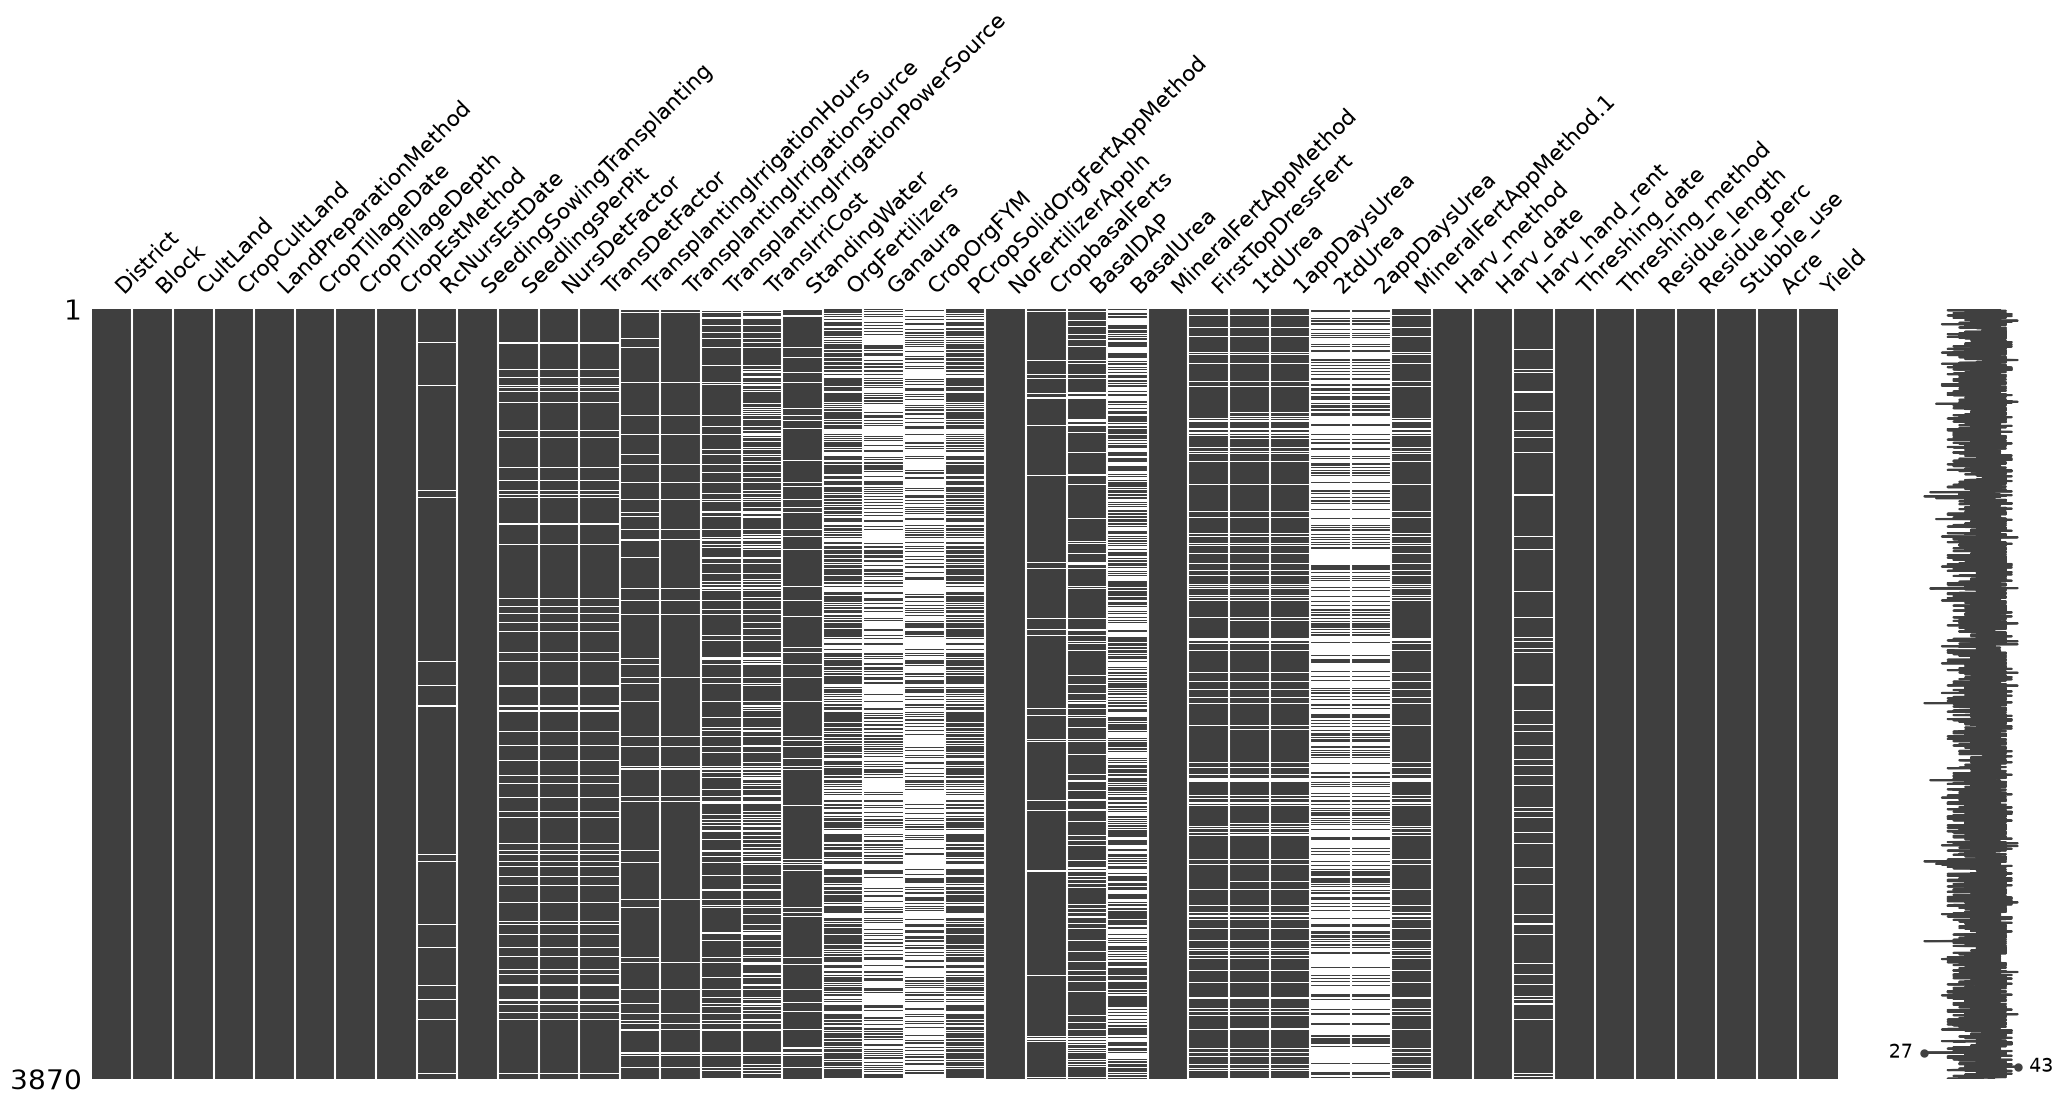

In [35]:
msno.matrix(train_data)

##### Exploring missingness in fertilizer doses/application

In [36]:
total_missing= train_data.isnull().sum().sort_values(ascending=False)
total_count=train_data.isnull().count().sort_values(ascending=False)
percent_missing=total_missing/total_count*100
missing_df=pd.concat([total_missing,percent_missing],axis=1,keys=['total_missing','percentage_missing'],sort=False)
missing_df=missing_df[total_missing>0] # only retain those with missing values 

missing_df

,total_missing,percentage_missing
2appDaysUrea,2700,69.767442
2tdUrea,2694,69.612403
CropOrgFYM,2674,69.095607
Ganaura,2417,62.454780
BasalUrea,1704,44.031008
PCropSolidOrgFertAppMethod,1337,34.547804
OrgFertilizers,1335,34.496124
TransIrriCost,882,22.790698
1tdUrea,556,14.366925
1appDaysUrea,556,14.366925


In [37]:
cols=['NoFertilizerAppln','BasalDAP','BasalUrea','1tdUrea','1appDaysUrea','2tdUrea','2appDaysUrea']

missing_data=train_data[cols]
missing_data[missing_data['NoFertilizerAppln']<2].head(20)

,NoFertilizerAppln,BasalDAP,BasalUrea,1tdUrea,1appDaysUrea,2tdUrea,2appDaysUrea
21,1,NaN,25.0,NaN,NaN,NaN,NaN
30,1,8.0,11.0,NaN,NaN,NaN,NaN
33,1,10.0,NaN,NaN,NaN,NaN,NaN
45,1,10.0,15.0,NaN,NaN,NaN,NaN
47,1,13.0,18.0,NaN,NaN,NaN,NaN
64,1,4.0,NaN,NaN,NaN,NaN,NaN
70,1,12.0,12.0,NaN,NaN,NaN,NaN
75,1,9.0,9.0,NaN,NaN,NaN,NaN
77,1,15.0,NaN,NaN,NaN,NaN,NaN
82,1,NaN,18.0,NaN,NaN,NaN,NaN


This confirms a hypothesis, that the features '1appDaysUrea' and '2appDaysUrea' are not mising at random, they are missing because the farmer actually did not apply the second and third dose of fertilizer. As a domain expert, because the timing of fertilizer application is just as important as the application itself, I am inclined not to drop the missing values- instead I will replace them with an out of range value like -0, this tells the model that the absence of the data point carries a specific meaning or pattern.

In [38]:
#impute missing values
train_data['BasalDAP'] = train_data['BasalDAP'].fillna(0)
train_data['BasalUrea'] = train_data['BasalUrea'].fillna(0)
train_data['1tdUrea'] = train_data['1tdUrea'].fillna(0)
train_data['2tdUrea'] = train_data['2tdUrea'].fillna(0)
train_data['1appDaysUrea'] = train_data['1appDaysUrea'].fillna(-1)
train_data['2appDaysUrea'] = train_data['2appDaysUrea'].fillna(-1)

##### Exploring missingness in organic fertilizer application

In [39]:
org_cols=['OrgFertilizers','Ganaura','CropOrgFYM','PCropSolidOrgFertAppMethod']

organic_data=train_data[org_cols]
organic_data.head(20)

,OrgFertilizers,Ganaura,CropOrgFYM,PCropSolidOrgFertAppMethod
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,Ganaura FYM,1.0,1.0,SoilApplied
3,Ganaura,1.0,NaN,SoilApplied
4,NaN,NaN,NaN,NaN
5,FYM,NaN,5.0,SoilApplied
6,Ganaura,1.0,NaN,SoilApplied
7,NaN,NaN,NaN,NaN
8,FYM,NaN,2.0,SoilApplied
9,NaN,NaN,NaN,NaN


In [40]:
#impute missing values
train_data['OrgFertilizers'] = train_data['OrgFertilizers'].fillna('No organic fertilizer applied')
train_data['Ganaura'] = train_data['Ganaura'].fillna(0)
train_data['CropOrgFYM'] = train_data['CropOrgFYM'].fillna(0)
train_data['PCropSolidOrgFertAppMethod'] = train_data['PCropSolidOrgFertAppMethod'].fillna('No organic fertilizer applied')

##### Exploring missingness in water/irrigation management

In [41]:
irri_cols=['TransIrriCost','TransplantingIrrigationPowerSource','TransplantingIrrigationHours','TransplantingIrrigationSource']

irrigation_data=train_data[irri_cols]
irrigation_data[irrigation_data.isnull()].head(20)

,TransIrriCost,TransplantingIrrigationPowerSource,TransplantingIrrigationHours,TransplantingIrrigationSource
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN


In [42]:
#impute missing values

train_data['TransIrriCost'] = train_data['TransIrriCost'].fillna(0)
train_data['TransplantingIrrigationPowerSource'] = train_data['TransplantingIrrigationPowerSource'].fillna('No irrigation')
train_data['TransplantingIrrigationHours'] = train_data['TransplantingIrrigationHours'].fillna(0)
train_data['TransplantingIrrigationSource'] = train_data['TransplantingIrrigationSource'].fillna('No irrigation')

In [43]:
missing_counts = train_data.isnull().sum().sort_values(ascending=False)
print(missing_counts[missing_counts > 0])

FirstTopDressFert         485
MineralFertAppMethod.1    481
SeedlingsPerPit           289
TransDetFactor            289
NursDetFactor             289
Harv_hand_rent            252
StandingWater             238
CropbasalFerts            188
RcNursEstDate              83
dtype: int64


For all the other missing values I will go ahead and drop all missing rows.

<Axes: >

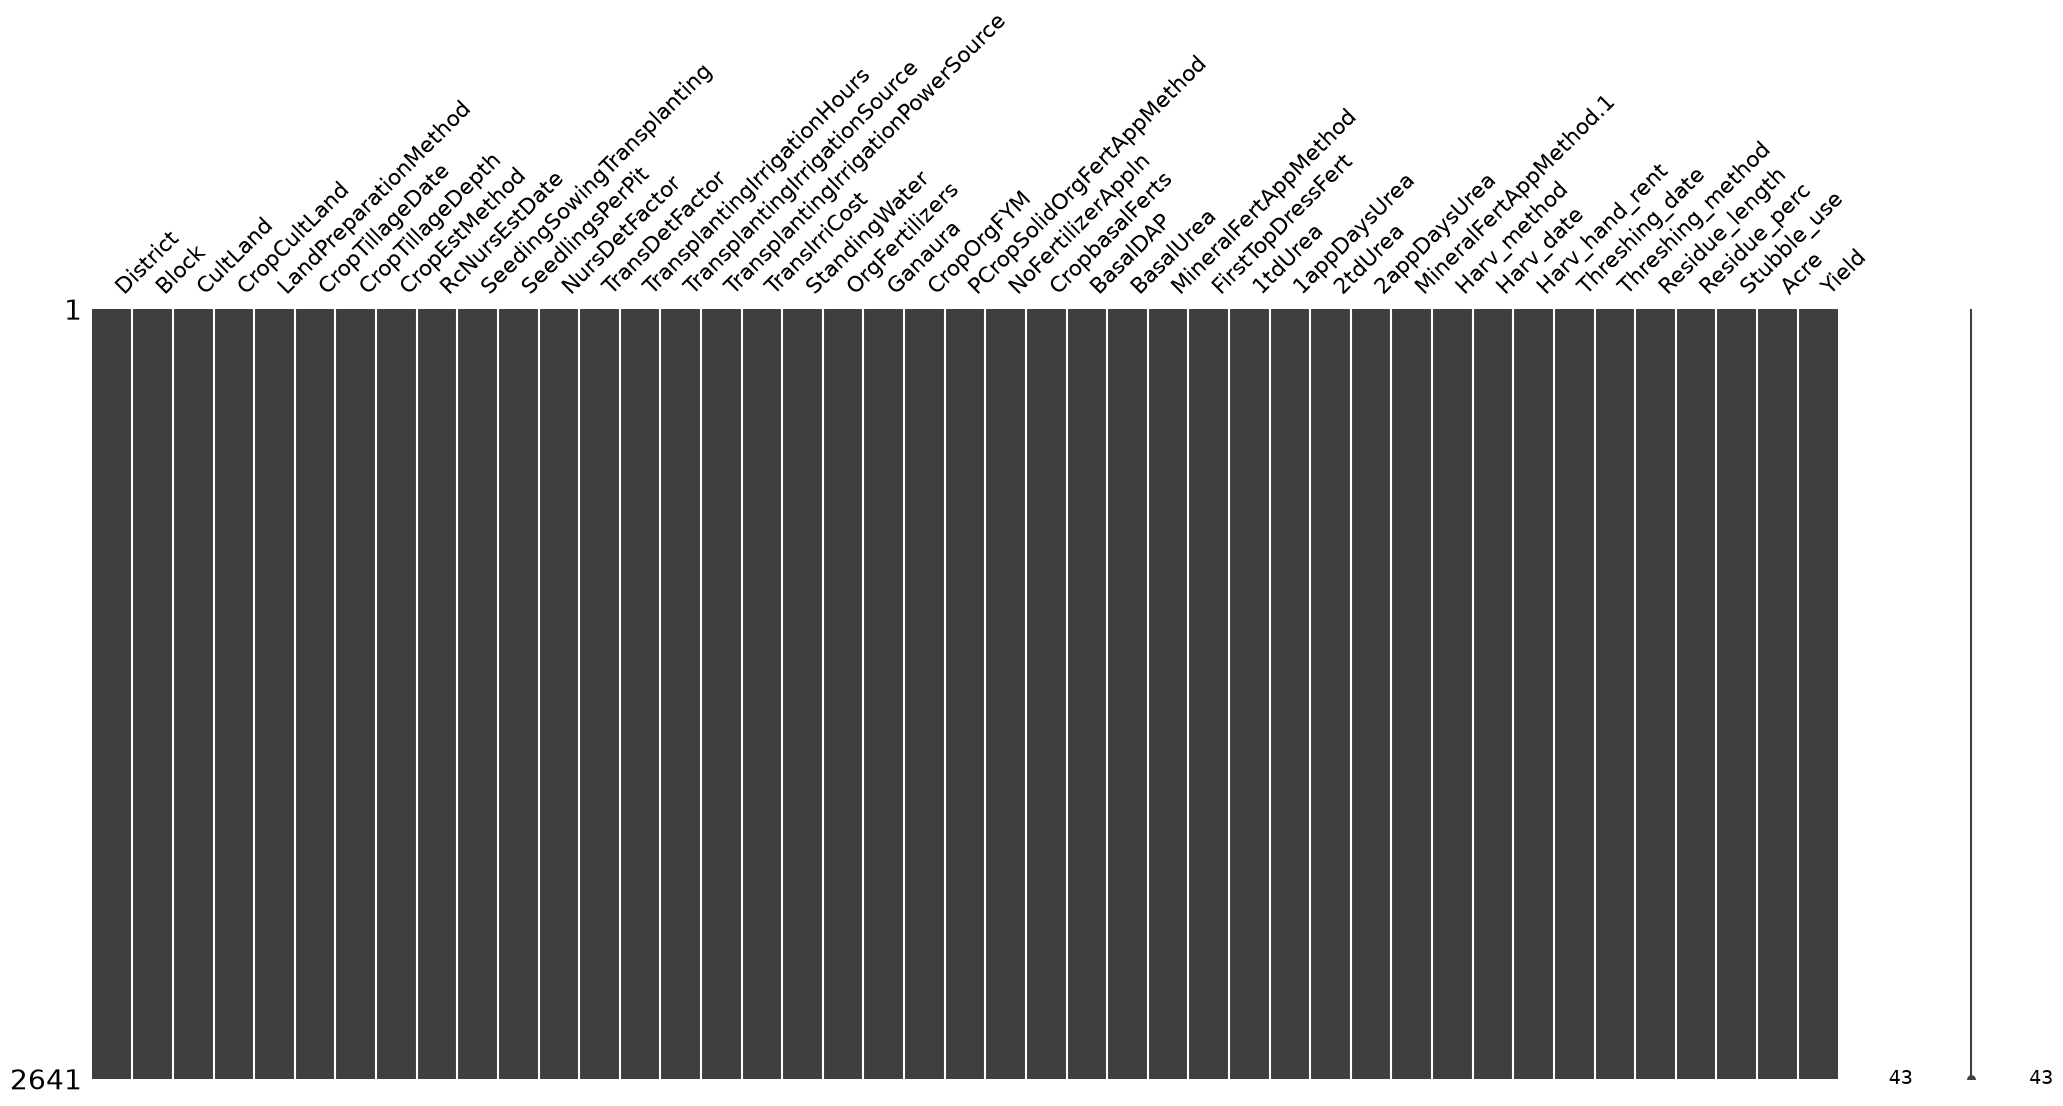

In [44]:
clean_data=train_data.dropna()
clean_data = clean_data.drop_duplicates()
msno.matrix(clean_data)

### 2.3 Exploratory Data Analysis

#### Univariate Analysis

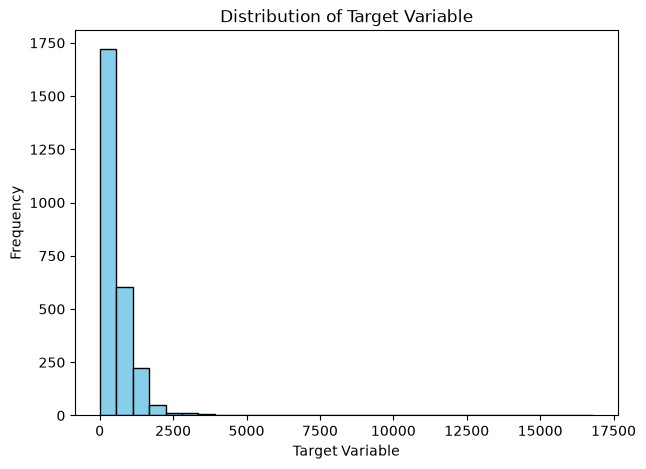

In [45]:
#spread of the target variable

plt.figure(figsize=(7,5))
plt.hist(clean_data['Yield'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Target Variable')
plt.ylabel('Frequency')
plt.title('Distribution of Target Variable')
plt.show()

Noticed some outliers in the yield variable, investigate with IQR.

In [46]:
q1 = clean_data['Yield'].quantile(0.25)
q3 = clean_data['Yield'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print(iqr)
print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")

480.0
Lower Bound: -450.0, Upper Bound: 1470.0


In [47]:
outlier_df=clean_data[(clean_data['Yield']<lower_bound) | (clean_data['Yield']>upper_bound)]
outlier_df.head(2)

,District,Block,CultLand,CropCultLand,LandPreparationMethod,CropTillageDate,CropTillageDepth,CropEstMethod,RcNursEstDate,SeedingSowingTransplanting,...,Harv_method,Harv_date,Harv_hand_rent,Threshing_date,Threshing_method,Residue_length,Residue_perc,Stubble_use,Acre,Yield
28,Jamui,Jamui,10,10,WetTillagePuddling TractorPlough BullockPlough,2022-07-08,4,Manual_PuddledRandom,2022-07-06,2022-07-26,...,hand,2022-11-09,300.0,2023-01-23,machine,26,10,plowed_in_soil,0.227273,4000
76,Jamui,Jamui,30,30,WetTillagePuddling TractorPlough BullockPlough,2022-08-13,4,Manual_PuddledRandom,2022-07-11,2022-08-17,...,hand,2022-11-16,1500.0,2023-01-25,machine,26,10,plowed_in_soil,1.363636,2400


In [48]:
outlier_df['Yield'].describe()

count      172.000000
mean      2370.994186
std       1875.566648
min       1500.000000
25%       1600.000000
50%       1790.000000
75%       2300.000000
max      16800.000000
Name: Yield, dtype: float64

I am going to assume all these were data entry errors and divide them by 10 to bring them within a reasonable range. This is a common technique for handling outliers in datasets where the values are suspected to be incorrectly recorded.

In [49]:
is_outlier = (clean_data['Yield'] < lower_bound) | (clean_data['Yield'] > upper_bound)
clean_data['Yield']= clean_data['Yield'].astype(float)
clean_data.loc[is_outlier, 'Yield'] = clean_data.loc[is_outlier, 'Yield'] / 10

#### Bivariate Analysis

#### Multivariate Analysis

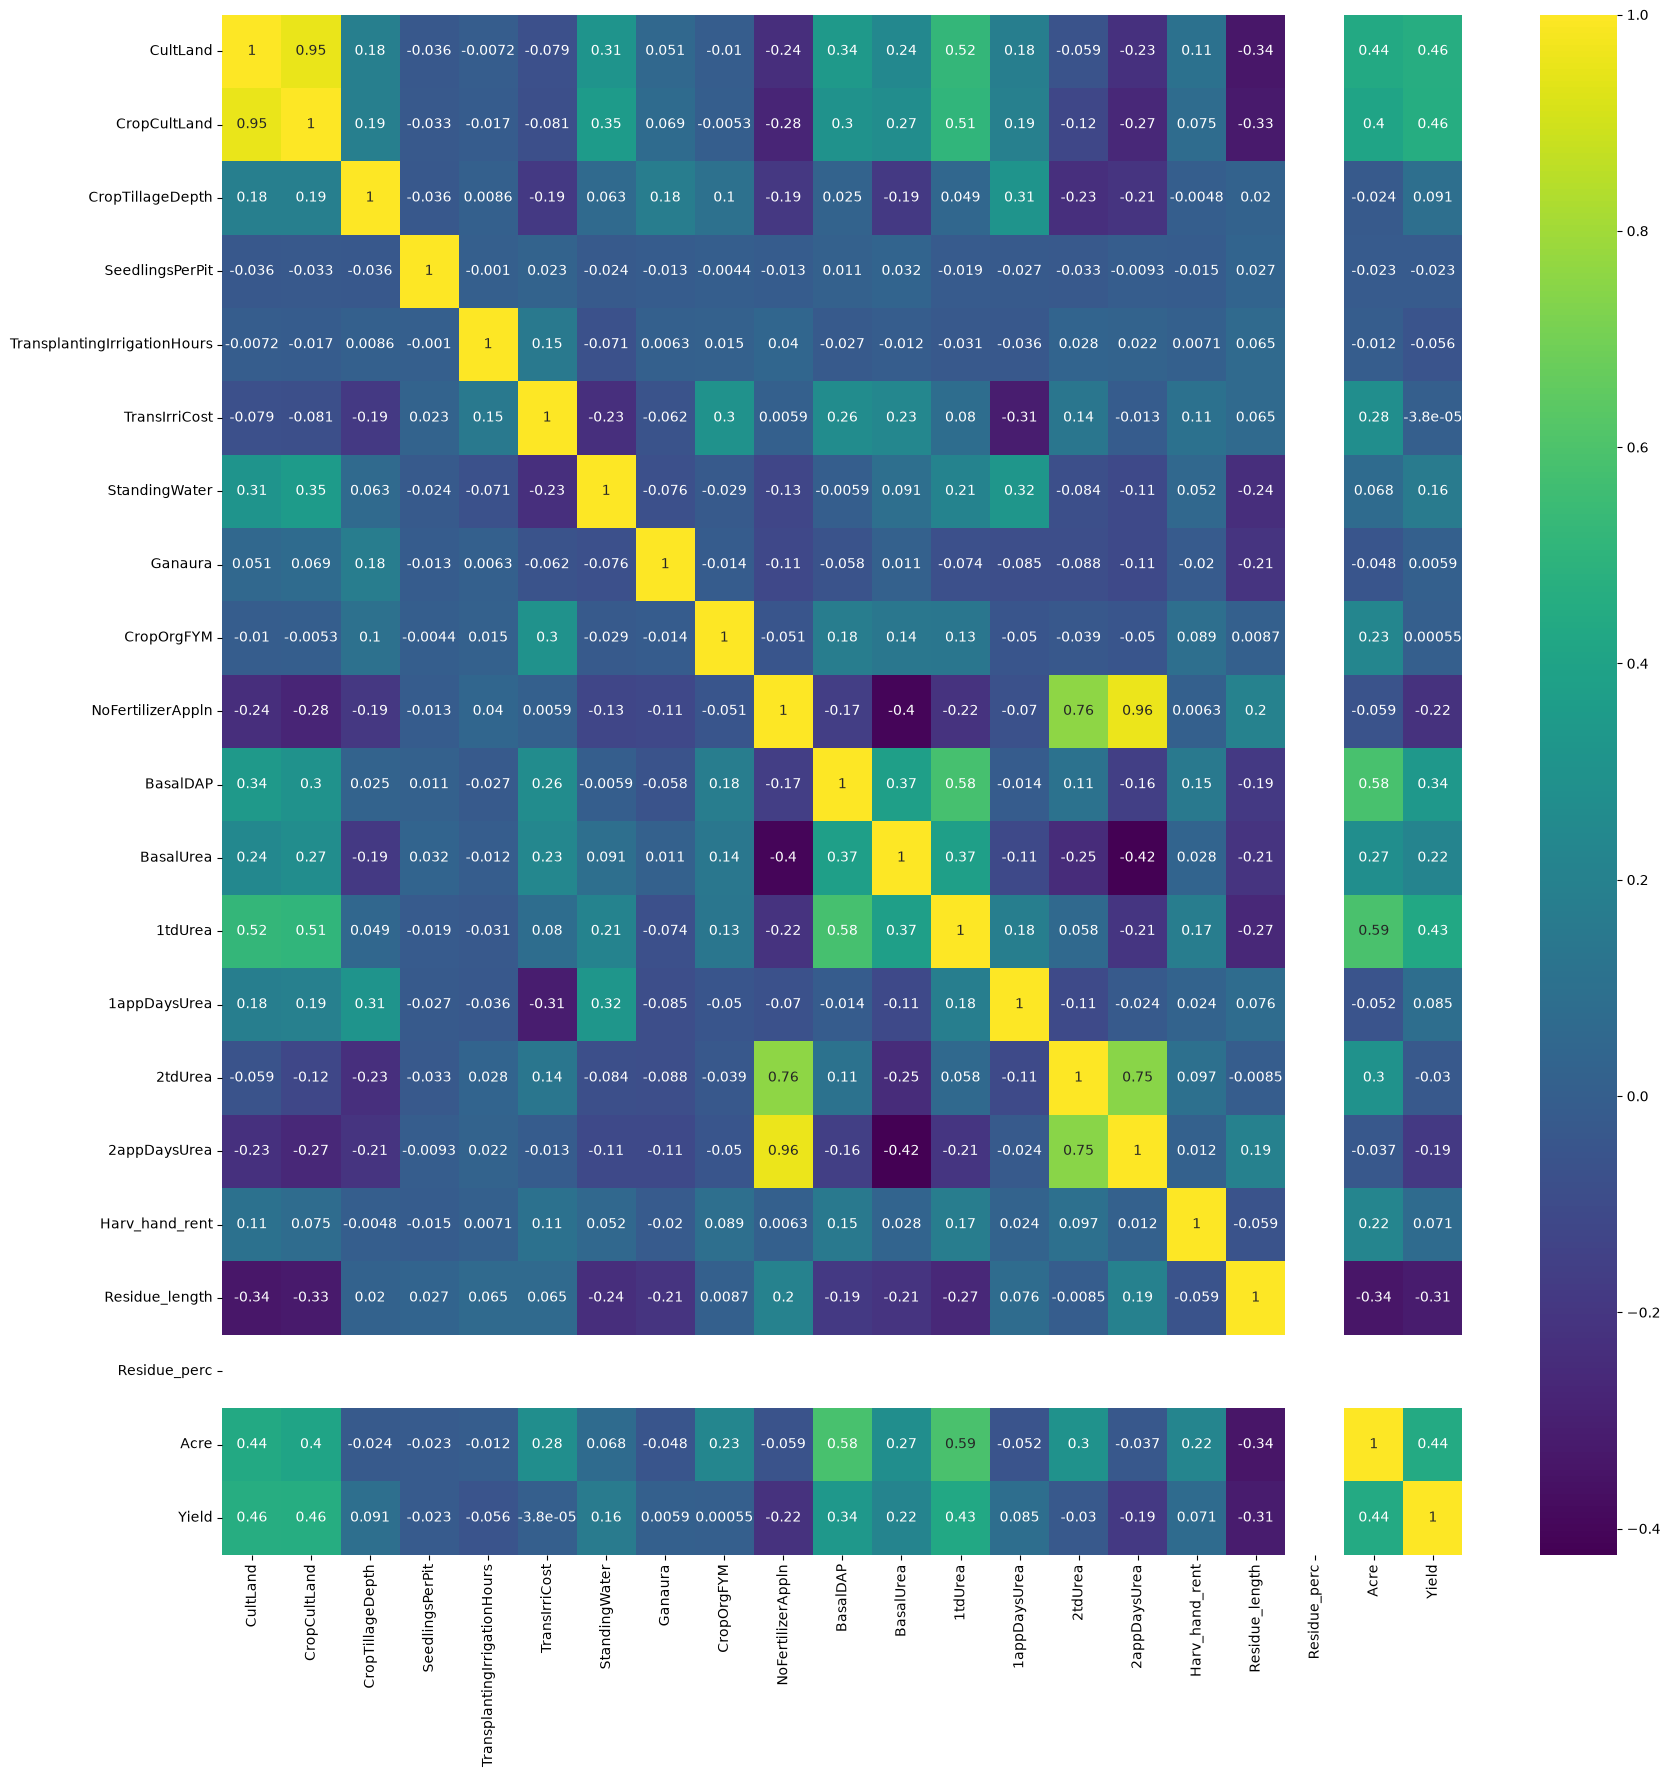

In [50]:
#correlation matrix
num_df = clean_data.select_dtypes(include=[np.number])  # Select only numeric columns
corrmat = num_df.corr()
top_corr_features = corrmat.index
plt.figure(figsize=(20,20))
g=sns.heatmap(num_df[top_corr_features].corr(),annot=True,cmap="viridis")

In [51]:
#go ahead and drop columns that are not useful for the model

clean_data.drop(columns= ['Residue_perc'],inplace=True)

## 3. Preparing the data for modelling

#### 3.1 Feature Engineering

We have a lot of datetime objects in this dataset, perfect candidates for feature engineering. In agriculture, the timing of certain agronomic practices is crucial to the health and potential yield of the crop. As such, from the temporal data we can extract the following:
* If land preparation was done at the required time in the season
* If the seedlings were transplanted at the right stage of maturity from nursery to farm
* If the growing season was long enough- no missed harvest/early harvest when crop has not reached peak maturity
* if post harvest practices were done at the correct time in the season

In [52]:
clean_data['GrowingSeasonDays'] = (clean_data['Harv_date'] - clean_data['SeedingSowingTransplanting']).dt.days
clean_data['NurseryToTransplantDays'] = (clean_data['SeedingSowingTransplanting'] - clean_data['RcNursEstDate']).dt.days
clean_data['TillageToTransplantDays'] = (clean_data['SeedingSowingTransplanting'] - clean_data['CropTillageDate']).dt.days
clean_data['HarvestToThreshingDays'] = (clean_data['Threshing_date'] - clean_data['Harv_date']).dt.days

We could also include some seasonal checks:
* Did the farmer plant in the correct month?
* Did they harvest in the correct month?

In [53]:
clean_data['PlantingMonth'] = clean_data['SeedingSowingTransplanting'].dt.month
clean_data['HarvestMonth'] = clean_data['Harv_date'].dt.month

Next we can go ahead and drop all the temporal columns...

In [54]:
clean_data.drop(columns=['RcNursEstDate','CropTillageDate','SeedingSowingTransplanting','Harv_date','Threshing_date'],inplace=True)

#### 3.2 Feature Selection


In [55]:
cat_df=clean_data.select_dtypes(include=[object])
num_df=clean_data.select_dtypes(include=[np.number])

C:\Users\Wambui\AppData\Local\Temp\ipykernel_16388\957579132.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_df=clean_data.select_dtypes(include=[object])


In [56]:
cat_df.head()

,District,Block,LandPreparationMethod,CropEstMethod,NursDetFactor,TransDetFactor,TransplantingIrrigationSource,TransplantingIrrigationPowerSource,OrgFertilizers,PCropSolidOrgFertAppMethod,CropbasalFerts,MineralFertAppMethod,FirstTopDressFert,MineralFertAppMethod.1,Harv_method,Threshing_method,Stubble_use
1,Nalanda,Rajgir,WetTillagePuddling TractorPlough FourWheelTrac...,Manual_PuddledRandom,CalendarDate PreMonsoonShowers IrrigWaterAvail...,CalendarDate SeedlingAge RainArrival IrrigWate...,Boring,Electric,No organic fertilizer applied,No organic fertilizer applied,DAP Urea,Broadcasting,Urea,Broadcasting,hand,machine,plowed_in_soil
2,Gaya,Gurua,TractorPlough FourWheelTracRotavator,Manual_PuddledRandom,PreMonsoonShowers IrrigWaterAvailability Labou...,SeedlingAge IrrigWaterAvailability LaborAvaila...,Boring,Electric,Ganaura FYM,SoilApplied,DAP,SoilApplied,Urea,RootApplication,hand,machine,plowed_in_soil
5,Vaishali,Garoul,TractorPlough,Manual_PuddledLine,CalendarDate SeedAvailability,CalendarDate SeedlingAge RainArrival IrrigWate...,Boring,Electric,FYM,SoilApplied,DAP Other,SoilApplied,Urea,Broadcasting,hand,hand,plowed_in_soil
6,Jamui,Khaira,TractorPlough,Manual_PuddledRandom,CalendarDate SeedAvailability,CalendarDate SeedlingAge RainArrival IrrigWate...,Canal,No irrigation,Ganaura,SoilApplied,DAP,Broadcasting,Urea,Broadcasting,hand,machine,plowed_in_soil
8,Jamui,Khaira,TractorPlough,Manual_PuddledRandom,CalendarDate SeedAvailability,CalendarDate SeedlingAge RainArrival IrrigWate...,Canal,No irrigation,FYM,SoilApplied,DAP,Broadcasting,Urea,Broadcasting,hand,machine,plowed_in_soil


When it comes to estimating the yield of a crop, feature selection is very important because- one should only include features that influence crop yield. This takes some domain knowledge.For example, 'NursDetFactor' and 'TransDetFactor' which are the reasons who choosing the date for nursery establishment and transplating respectively- do not have a direct impact on crop yield. They may be used to identify any gaps in the farmers' agronomy knowledge but not necessarily predict yield. So these categorical columns can be dropped!

In [57]:
cat_df.drop(columns=['TransDetFactor','NursDetFactor'],inplace=True)

In [58]:
num_df.head()

,CultLand,CropCultLand,CropTillageDepth,SeedlingsPerPit,TransplantingIrrigationHours,TransIrriCost,StandingWater,Ganaura,CropOrgFYM,NoFertilizerAppln,...,Harv_hand_rent,Residue_length,Acre,Yield,GrowingSeasonDays,NurseryToTransplantDays,TillageToTransplantDays,HarvestToThreshingDays,PlantingMonth,HarvestMonth
1,26,26,5,2.0,5.0,125.0,3.0,0.0,0.0,2,...,3.0,24,0.312500,600.0,128,30,2,29,7,11
2,10,10,6,2.0,4.0,80.0,2.0,1.0,1.0,2,...,480.0,30,0.148148,225.0,121,54,44,30,8,12
5,10,5,6,1.0,1.0,0.0,3.0,0.0,5.0,2,...,600.0,30,0.136364,205.0,110,21,4,11,7,10
6,12,12,3,4.0,1.0,0.0,6.0,1.0,0.0,3,...,130.0,25,0.136364,270.0,97,25,7,34,7,11
8,25,25,4,4.0,2.0,0.0,5.0,0.0,2.0,3,...,130.0,26,0.227273,425.0,97,24,9,38,8,11


#### 3.3 Feature Encoding

In [59]:
cat_df.head()

,District,Block,LandPreparationMethod,CropEstMethod,TransplantingIrrigationSource,TransplantingIrrigationPowerSource,OrgFertilizers,PCropSolidOrgFertAppMethod,CropbasalFerts,MineralFertAppMethod,FirstTopDressFert,MineralFertAppMethod.1,Harv_method,Threshing_method,Stubble_use
1,Nalanda,Rajgir,WetTillagePuddling TractorPlough FourWheelTrac...,Manual_PuddledRandom,Boring,Electric,No organic fertilizer applied,No organic fertilizer applied,DAP Urea,Broadcasting,Urea,Broadcasting,hand,machine,plowed_in_soil
2,Gaya,Gurua,TractorPlough FourWheelTracRotavator,Manual_PuddledRandom,Boring,Electric,Ganaura FYM,SoilApplied,DAP,SoilApplied,Urea,RootApplication,hand,machine,plowed_in_soil
5,Vaishali,Garoul,TractorPlough,Manual_PuddledLine,Boring,Electric,FYM,SoilApplied,DAP Other,SoilApplied,Urea,Broadcasting,hand,hand,plowed_in_soil
6,Jamui,Khaira,TractorPlough,Manual_PuddledRandom,Canal,No irrigation,Ganaura,SoilApplied,DAP,Broadcasting,Urea,Broadcasting,hand,machine,plowed_in_soil
8,Jamui,Khaira,TractorPlough,Manual_PuddledRandom,Canal,No irrigation,FYM,SoilApplied,DAP,Broadcasting,Urea,Broadcasting,hand,machine,plowed_in_soil


In this data we have some very high cardinal data- fix that by treating high cardinal categorical features slightly different from low cardinal data.

In [60]:
for cols in cat_df.columns:
    print(f"{cols}: {cat_df[cols].nunique()} unique values")


District: 4 unique values
Block: 9 unique values
LandPreparationMethod: 37 unique values
CropEstMethod: 2 unique values
TransplantingIrrigationSource: 7 unique values
TransplantingIrrigationPowerSource: 4 unique values
OrgFertilizers: 28 unique values
PCropSolidOrgFertAppMethod: 5 unique values
CropbasalFerts: 24 unique values
MineralFertAppMethod: 3 unique values
FirstTopDressFert: 11 unique values
MineralFertAppMethod.1: 3 unique values
Harv_method: 1 unique values
Threshing_method: 2 unique values
Stubble_use: 2 unique values


In [61]:
#separate the categorical features with high cardinality from those with low cardinality
high_cardinality_cols = [col for col in cat_df.columns if cat_df[col].nunique() > 10]
low_cardinality_cols = [col for col in cat_df.columns if cat_df[col].nunique() <= 10]

In [62]:
#encode using one hot encoding for the low cardinality features
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False)

encoded=ohe.fit_transform(cat_df[low_cardinality_cols].astype(str))
encoded_df=pd.DataFrame(encoded,columns=ohe.get_feature_names_out(low_cardinality_cols))
encoded_df.head()

,District_Gaya,District_Jamui,District_Nalanda,District_Vaishali,Block_Chehrakala,Block_Garoul,Block_Gurua,Block_Jamui,Block_Khaira,Block_Mahua,...,MineralFertAppMethod_RootApplication,MineralFertAppMethod_SoilApplied,MineralFertAppMethod.1_Broadcasting,MineralFertAppMethod.1_RootApplication,MineralFertAppMethod.1_SoilApplied,Harv_method_hand,Threshing_method_hand,Threshing_method_machine,Stubble_use_burned,Stubble_use_plowed_in_soil
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
2,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0


In [70]:
encoded_df=encoded_df.reset_index(drop=True)
num_df=num_df.reset_index(drop=True)
target_df=pd.DataFrame(cat_df[high_cardinality_cols])
target_df=target_df.reset_index(drop=True)
df2=pd.concat([num_df, encoded_df, target_df], axis=1)
df2.head()


,CultLand,CropCultLand,CropTillageDepth,SeedlingsPerPit,TransplantingIrrigationHours,TransIrriCost,StandingWater,Ganaura,CropOrgFYM,NoFertilizerAppln,...,MineralFertAppMethod.1_SoilApplied,Harv_method_hand,Threshing_method_hand,Threshing_method_machine,Stubble_use_burned,Stubble_use_plowed_in_soil,LandPreparationMethod,OrgFertilizers,CropbasalFerts,FirstTopDressFert
0,26,26,5,2.0,5.0,125.0,3.0,0.0,0.0,2,...,0.0,1.0,0.0,1.0,0.0,1.0,WetTillagePuddling TractorPlough FourWheelTrac...,No organic fertilizer applied,DAP Urea,Urea
1,10,10,6,2.0,4.0,80.0,2.0,1.0,1.0,2,...,0.0,1.0,0.0,1.0,0.0,1.0,TractorPlough FourWheelTracRotavator,Ganaura FYM,DAP,Urea
2,10,5,6,1.0,1.0,0.0,3.0,0.0,5.0,2,...,0.0,1.0,1.0,0.0,0.0,1.0,TractorPlough,FYM,DAP Other,Urea
3,12,12,3,4.0,1.0,0.0,6.0,1.0,0.0,3,...,0.0,1.0,0.0,1.0,0.0,1.0,TractorPlough,Ganaura,DAP,Urea
4,25,25,4,4.0,2.0,0.0,5.0,0.0,2.0,3,...,0.0,1.0,0.0,1.0,0.0,1.0,TractorPlough,FYM,DAP,Urea


#### 3.4 Train-Test split

The next step is to split your data because the subsequent pre-processing steps involve computing some statistics from your data. And since we want to avoid data leakage- model learning from the statistics in the test, which is supposed to be STRICTLY UNSEEN to the model, we split before we apply ANY pre-processing steps.

In [71]:
X=df2.drop('Yield',axis=1)
y=df2[['Yield']]

In [72]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split (X, y, test_size=0.20, random_state=20)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(2112, 71) (529, 71) (2112, 1) (529, 1)


## 4. Model Building & Training

#### 4.1 Pipeline design
To avoid any issues with data leakage- we use pipelines.

In [73]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import make_scorer, mean_squared_error, root_mean_squared_error

In [81]:
#now build the pipeline for the model using the new features- first with random forest regressor

from sklearn.preprocessing import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

rmse_score = make_scorer(root_mean_squared_error)


te = TargetEncoder(
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    target_type="continuous",  # yield estimation is regression
)

preprocessor = ColumnTransformer(
    transformers=[
        ('target_enc', te, high_cardinality_cols)
    ],
    remainder='passthrough' # Keeps all other numerical/encoded features intact
)



# 2. Build the pipeline
rfr_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('rfr', RandomForestRegressor(n_estimators=100, random_state=42))
])

scores = cross_val_score(rfr_pipe, X_train, y_train.values.ravel(), cv=5, scoring=rmse_score)
print("RMSE Scores for each fold: ", scores)      
print("Mean RMSE: ", scores.mean())

RMSE Scores for each fold:  [151.66772059 172.83420477 181.34586002 153.64059831 136.24113631]
Mean RMSE:  159.14590400197312


In [82]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    estimator=rfr_pipe,
    X=X_train,
    y=y_train.values.ravel(),
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring="neg_root_mean_squared_error",
    shuffle=True,
    random_state=42
)



In [83]:
#since we used cross validation, calculate the means
train_scores_mean = train_scores.mean(axis=1)*(-1)
validation_scores_mean = val_scores.mean(axis=1)*(-1)

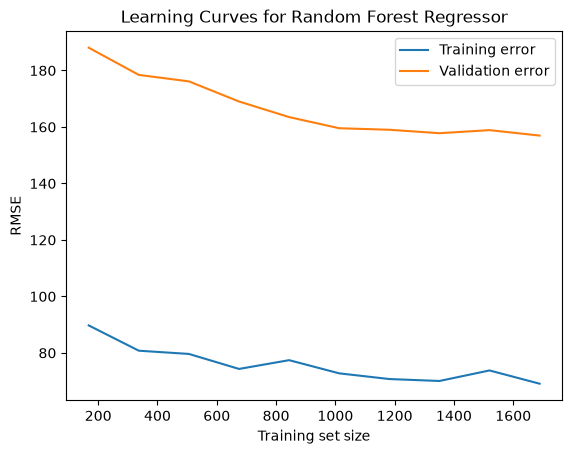

In [84]:
plt.plot(train_sizes, train_scores_mean, label = 'Training error')
plt.plot(train_sizes, validation_scores_mean, label = 'Validation error')

plt.ylabel('RMSE')
plt.xlabel('Training set size')
plt.title('Learning Curves for Random Forest Regressor')
plt.legend()
plt.show()

In [85]:
# Same pipeline as above, now with Gradient Boosting Regressor

from sklearn.ensemble import GradientBoostingRegressor



gb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('gb', GradientBoostingRegressor(n_estimators=100, random_state=42, learning_rate=0.1))
])

# 3. Evaluate the pipeline
scores = cross_val_score(gb_pipe, X_train, y_train.values.ravel(), cv=5, scoring=rmse_score)
print("RMSE Scores for each fold: ", scores)      
print("Mean RMSE: ", scores.mean())

RMSE Scores for each fold:  [149.87479301 162.50416193 190.94294762 164.42978665 148.72040557]
Mean RMSE:  163.29441895646968


In [86]:
train_sizes, train_scores, val_scores = learning_curve(
    estimator=gb_pipe,
    X=X_train,
    y=y_train.values.ravel(),
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring="neg_root_mean_squared_error",
    shuffle=True,
    random_state=42
)

In [87]:
train_scores_mean = train_scores.mean(axis=1)*(-1)
validation_scores_mean = val_scores.mean(axis=1)*(-1)

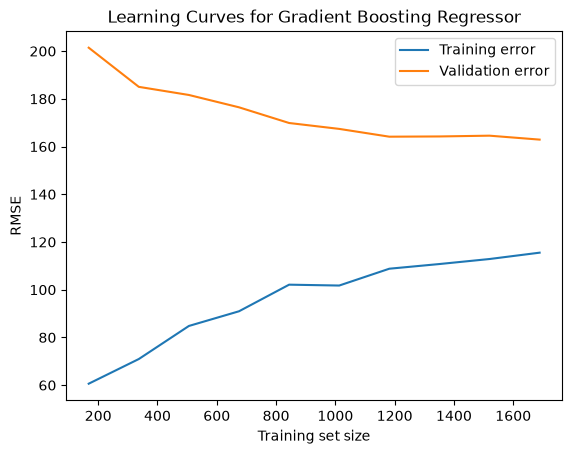

In [88]:
plt.plot(train_sizes, train_scores_mean, label = 'Training error')
plt.plot(train_sizes, validation_scores_mean, label = 'Validation error')
plt.ylabel('RMSE')
plt.xlabel('Training set size')
plt.title('Learning Curves for Gradient Boosting Regressor')
plt.legend()
plt.show()

In [89]:
# Same pipeline as above, now with XGBoost Regressor

from xgboost import XGBRegressor  # 1. Import XGBoost Regressor


xgb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('xgb', XGBRegressor(n_estimators=100, random_state=42,learning_rate=0.1))
])

# 3. Evaluate the pipeline
scores = cross_val_score(xgb_pipe, X_train, y_train.values.ravel(), cv=5, scoring=rmse_score)
print("RMSE Scores for each fold: ", scores)      
print("Mean RMSE: ", scores.mean())

RMSE Scores for each fold:  [145.67182993 173.1274871  185.42165517 149.94050258 138.05472495]
Mean RMSE:  158.44323994478844


In [90]:
train_scores_mean = train_scores.mean(axis=1)*(-1)
validation_scores_mean = val_scores.mean(axis=1)*(-1)

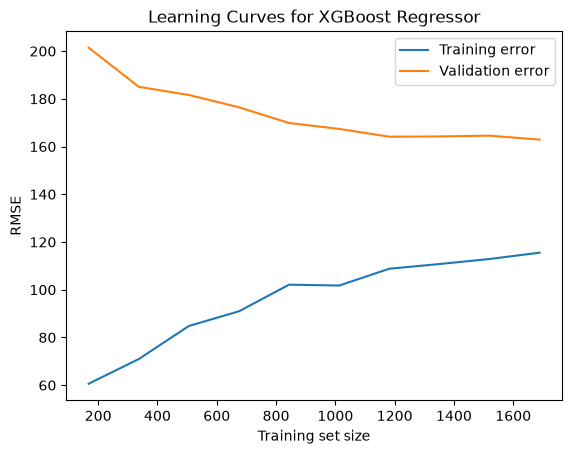

In [91]:
plt.plot(train_sizes, train_scores_mean, label = 'Training error')
plt.plot(train_sizes, validation_scores_mean, label = 'Validation error')
plt.ylabel('RMSE')
plt.xlabel('Training set size')
plt.title('Learning Curves for XGBoost Regressor')
plt.legend()
plt.show()

#### Best Candidate Model for Hyperparameter Tuning!
From the RMSE scores, the best performing model was the XGBoost Regressor!

## 5. HyperParameter Tuning

In [101]:
from sklearn.model_selection import GridSearchCV



param_grid = {
    'xgb__n_estimators': [50, 100,200,300],
    'xgb__max_depth': [3, 5, 6, 10],
    'xgb__learning_rate': [0.1, 0.01,1],
    }

grid_search = GridSearchCV(estimator=xgb_pipe, param_grid=param_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train.values.ravel())

print("Best Hyperparameters:", grid_search.best_params_)
print("Best Cross-Validation Score (rmse):", -grid_search.best_score_)

Best Hyperparameters: {'xgb__learning_rate': 0.1, 'xgb__max_depth': 5, 'xgb__n_estimators': 100}
Best Cross-Validation Score (rmse): 155.60997816724168


In [102]:
best_model = grid_search.best_estimator_

test_pred = best_model.predict(X_test)
test_rmse = root_mean_squared_error(y_test.values.ravel(), test_pred)
print(f'CV RMSE:      {-grid_search.best_score_:.1f}')
print(f'Held-out RMSE: {test_rmse:.1f}')

CV RMSE:      155.6
Held-out RMSE: 165.4


In [103]:
#retrain your model on the best 
#Best model was that during training- 100 estimators,and learning rate of 0.1
# save that model as a pickle file

import pickle
with open('yield_predict.pkl', 'wb') as file:
    pickle.dump(best_model, file)

## Preparing the submission file

First we apply the same preprocessing steps to the test data.

In [106]:
with open('yield_predict.pkl', 'rb') as file:
    model = pickle.load(file)

In [107]:
test_df= test_data[X.columns]
preds = model.predict(test_df.fillna(0))

# Create submisiion file to be uploaded to Zindi for scoring
sub = pd.DataFrame({'ID': test_data.ID, 'Yield': preds})
sub.to_csv('BenchmarkSubmission.csv', index = False)

sub.head()

KeyError: "['GrowingSeasonDays', 'NurseryToTransplantDays', 'TillageToTransplantDays', 'HarvestToThreshingDays', 'PlantingMonth', 'HarvestMonth', 'District_Gaya', 'District_Jamui', 'District_Nalanda', 'District_Vaishali', 'Block_Chehrakala', 'Block_Garoul', 'Block_Gurua', 'Block_Jamui', 'Block_Khaira', 'Block_Mahua', 'Block_Noorsarai', 'Block_Rajgir', 'Block_Wazirganj', 'CropEstMethod_Manual_PuddledLine', 'CropEstMethod_Manual_PuddledRandom', 'TransplantingIrrigationSource_Boring', 'TransplantingIrrigationSource_Canal', 'TransplantingIrrigationSource_No irrigation', 'TransplantingIrrigationSource_Pond', 'TransplantingIrrigationSource_Rainfed', 'TransplantingIrrigationSource_TubeWell', 'TransplantingIrrigationSource_Well', 'TransplantingIrrigationPowerSource_Diesel', 'TransplantingIrrigationPowerSource_Electric', 'TransplantingIrrigationPowerSource_No irrigation', 'TransplantingIrrigationPowerSource_Solar', 'PCropSolidOrgFertAppMethod_Broadcasting', 'PCropSolidOrgFertAppMethod_No organi